# Smart Cargo E-Bike: an incremental multi-domain digital twin

**What you will be able to do after this notebook.** Build a physically faithful
simulation of a cargo e-bike *one system at a time* — starting from a
hand-written point mass and ending at a four-domain acausal model with a battery,
a motor, thermal coupling, a rider, and a legal speed-cutoff event — and use
Jaxonomy to differentiate it, reduce it, optimize it, and verify it by
conservation of energy.

We grow **one** artifact through four stages (v0 → v3) and then meet the
production model it converges to. Each stage introduces exactly one new Jaxonomy
capability and keeps every earlier one.

*Estimated reading time:* 35–45 min. *Runtime on CPU:* ≈ 2 min with the shipped
publication checkpoint (`media/ebike_smart_cargo_publication.npz`); the live
teaching cells (v0–v2, autodiff, ROM) each run in a few seconds.

> **Prerequisites.** Comfort with ODEs and basic vehicle/electrical physics. No
> prior Jaxonomy needed — we introduce `LeafSystem`, `DiagramBuilder`,
> `simulate`, the acausal engine, autodiff-through-simulation, ROM surrogates,
> and hybrid events as we go. If you want a gentler first look at a single
> `LeafSystem` with a hybrid event, the `bouncing_ball` and
> `hybrid_thermostat` examples in this folder are good warm-ups.

## The engineering question

A longtail **cargo e-bike** carries a rider plus ~60 kg of payload, is legally
capped at 25 km/h of motor assist (EU Class-1), and must not cook its battery or
motor on a long climb. A manufacturer wants to answer concrete questions *before*
building hardware:

- How much battery does a given assist policy actually spend on a real drive
  cycle, and can we cut it without slowing the bike down?
- Does the motor overheat on a sustained grade with a heavy load?
- Where exactly does assist cut out, and does the bike behave lawfully afterward?

Answering these needs a model that couples **four physical domains** —
electrical (battery + motor), rotational (drivetrain), translational (the vehicle
on the road), and thermal — plus the **control** logic that ties them together.
That is a lot to build at once, so we build it incrementally and check our work
at every step.

| Stage | Adds | New Jaxonomy capability |
|---|---|---|
| **v0** | point mass on a grade, constant tractive force | `LeafSystem`, `DiagramBuilder`, `simulate` |
| **v1** | electrical powertrain (battery → motor → wheel) | the **acausal** engine (effort/flow ports → DAE) |
| **v2** | thermal coupling + a reduced-order cooling map | cross-domain acausal + `fit_rbf` surrogate |
| **v3** | assist control + legal-speed cutoff | hybrid **zero-crossing events** |
| **full** | the production model, verified & optimized | energy audit, derivative-free trajectory opt |

The full model, its energy audit, and its optimizer already live in
`ebike_hybrid_simulation.py`, `ebike_thermal_rom.py`, and
`ebike_trajectory_optimization.py` in this folder; the last section imports them.

## Setup

One import cell for the whole notebook, grouped stdlib → third-party → Jaxonomy.
We work in float64 (Jaxonomy enables it by default) because energy audits and
stiff DAEs need the precision.

In [1]:
# stdlib
import os

# third-party
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# jaxonomy — core framework + simulation
import jaxonomy
from jaxonomy.framework import LeafSystem
from jaxonomy.simulation import SimulatorOptions
# jaxonomy — library blocks used by the primitives-based build
from jaxonomy.library import Integrator, FeedthroughBlock
# jaxonomy — the acausal (equation-based) engine
from jaxonomy.acausal import (
    AcausalCompiler, AcausalDiagram, EqnEnv,
    electrical as elec, rotational as rot, thermal as therm,
)
# jaxonomy — reduced-order modeling + diagnostics
from jaxonomy.library.rom import fit_rbf, RadialBasisSurrogate
from jaxonomy import diagnostics

RNG_SEED = 0
G = 9.81  # gravitational acceleration [m/s^2]
np.random.seed(RNG_SEED)
plt.rcParams["figure.dpi"] = 110
print("jaxonomy", jaxonomy.version if isinstance(jaxonomy.version, str) else jaxonomy.__version__ if hasattr(jaxonomy, "__version__") else "(dev)")
print("float64 active:", jnp.zeros(1).dtype == jnp.float64)

jaxonomy 3.1.0
float64 active: True


## Symbols and the calibration

We fix a naming convention now and reuse it throughout. Bold lowercase are
vectors, bold uppercase matrices, Greek are parameters/angles.

| Symbol | Meaning | Units |
|---|---|---|
| $m$ | total mass (bike + rider + cargo) | kg |
| $v$ | vehicle longitudinal speed | m/s |
| $r_w$ | loaded wheel radius | m |
| $C_{rr}$ | rolling-resistance coefficient | – |
| $C_dA$ | drag area ($C_d\cdot A$) | m² |
| $\rho$ | air density | kg/m³ |
| $\theta$ | road grade angle ($\tan\theta=$ slope) | rad |
| $F_\text{trac}$ | tractive force at the contact patch | N |
| $V$, $I$ | pack terminal voltage, current | V, A |
| $K_t$, $K_e$ | motor torque / back-EMF constants | Nm/A, Vs/rad |
| $\omega$ | shaft angular velocity | rad/s |
| $T$ | temperature | K (plotted °C) |
| $C_\text{th}$, $R_\text{th}$ | thermal capacitance / resistance | J/K, K/W |
| $h(v)$ | speed-dependent cooling conductance | W/K |

The numbers below describe a real Class-1 longtail (13S/15 Ah/~48 V pack, ~250 W
nominal). They are *nameable physical quantities*, not fitting knobs — a
discipline that pays off when the energy audit has to close.

In [2]:
# Reference calibration (shared by every stage). Real quantities, not knobs.
M_TOTAL = 180.0   # bike+rider 120 + cargo 60 [kg]
R_WHEEL = 0.29    # loaded rolling radius [m]
CRR     = 0.008   # rolling resistance coefficient (asphalt)
CDA     = 0.80    # drag area Cd*A [m^2] (upright rider + cargo)
RHO_AIR = 1.20    # air density [kg/m^3]
V_PACK  = 48.0    # nominal pack voltage [V]
print(f"Total mass {M_TOTAL:.0f} kg | CdA {CDA} m^2 | Crr {CRR} | wheel {R_WHEEL} m")

Total mass 180 kg | CdA 0.8 m^2 | Crr 0.008 | wheel 0.29 m


## v0 — a point mass on a grade

The smallest honest model of a bike is a point mass rolling on a road, pushed by
a constant tractive force and fought by three resistances. Newton's second law
along the direction of travel gives

$$ m\,\dot v \;=\; F_\text{trac} \;-\; \underbrace{\tfrac12\,\rho\,C_dA\,v\,|v|}_{\text{aero drag}}
\;-\; \underbrace{C_{rr}\,m\,g\,\mathrm{sgn}(v)}_{\text{rolling}}
\;-\; \underbrace{m\,g\,\sin\theta}_{\text{grade}}. \tag{1} $$

**Why each term.** Aerodynamic drag grows with the *square* of speed (the $v|v|$
keeps the sign right when reversing); a quick units check: $[\rho\,C_dA\,v^2] =
\mathrm{(kg/m^3)(m^2)(m/s)^2 = kg\,m/s^2 = N}$ ✓. Rolling resistance is roughly
constant in magnitude and opposes motion, so it carries $\mathrm{sgn}(v)$ (we
smooth it with $\tanh(v/\varepsilon)$ so the ODE solver never hits a true kink at
$v=0$). Gravity along the slope is $mg\sin\theta$ — the term that makes hills
hurt.

We implement (1) as a **`LeafSystem`**: the atomic building block of Jaxonomy. A
leaf declares its *state*, its *ordinary differential equation*, and its *output
ports*. Here the state is $\mathbf{x}=[x, v]$ (position and speed), the ODE is
(1), and we output speed.

In [3]:
class PointMassEbike(LeafSystem):
    '''v0: longitudinal point mass on a constant grade, constant tractive force.

    parameters : m, r_wheel, Crr, CdA, rho, grade, F_trac  (fixed at construction)
    state      : [x, v]  (position [m], speed [m/s])   -- continuous
    inputs     : none (open-loop constant force)
    outputs    : speed [m/s]
    '''
    def __init__(self, m=M_TOTAL, r_wheel=R_WHEEL, Crr=CRR, CdA=CDA, rho=RHO_AIR,
                 grade=0.04, F_trac=180.0, name="point_mass"):
        super().__init__(name=name)
        self.m, self.Crr, self.CdA, self.rho = m, Crr, CdA, rho
        self.grade, self.F_trac = grade, F_trac
        # A length-2 continuous state [x, v]; `ode` returns d/dt of the same shape.
        self.declare_continuous_state(shape=(2,), ode=self.ode)
        # One output port reading speed off the state (no inputs needed).
        self.declare_output_port(self.out_speed, name="speed", requires_inputs=False)

    def ode(self, time, state, *inputs, **params):
        x, v = state.continuous_state
        F_drag  = 0.5 * self.rho * self.CdA * v * jnp.sqrt(v**2 + 1e-6)
        F_roll  = self.Crr * self.m * G * jnp.tanh(v / 0.3)      # smoothed sgn(v)
        F_grade = self.m * G * jnp.sin(jnp.arctan(self.grade))   # slope -> angle
        dv = (self.F_trac - F_drag - F_roll - F_grade) / self.m
        return jnp.array([v, dv])                                # [dx/dt, dv/dt]

    def out_speed(self, time, state, *inputs, **params):
        return state.continuous_state[1:2]

To run it we build a one-block **diagram**, create a `Context` (the container for
state + parameters), set the initial condition, and call `simulate`. We keep the
horizon short (20 s) so every live cell finishes in seconds. `SimulatorOptions`
picks the solver and tolerances; `recorded_signals` names which ports to log.

In [4]:
v0 = PointMassEbike(grade=0.04, F_trac=180.0)
ctx0 = v0.create_context().with_continuous_state(jnp.array([0.0, 0.0]))  # start at rest
opts0 = SimulatorOptions(rtol=1e-6, atol=1e-8, max_major_steps=2000)
res0 = jaxonomy.simulate(v0, ctx0, (0.0, 20.0), options=opts0,
                         recorded_signals={"speed": v0.output_ports[0]})

t0 = np.asarray(res0.time)
speed0 = np.asarray(res0.outputs["speed"]).squeeze()
print(f"v0 terminal speed: {speed0[-1]*3.6:5.2f} km/h  (a 4% grade, 180 N of push)")

22:41:27.433 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=2000, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=PointMassEbike(system_id=1, name='point_mass', ui_id=None, parent=None), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


v0 terminal speed: 32.32 km/h  (a 4% grade, 180 N of push)


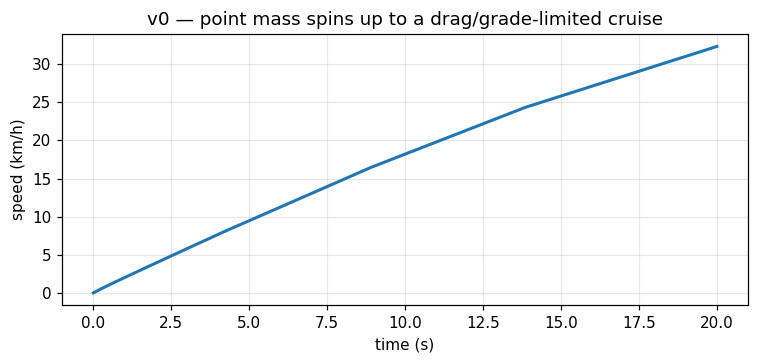

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(t0, speed0 * 3.6, color="tab:blue", lw=2)
ax.set_xlabel("time (s)"); ax.set_ylabel("speed (km/h)")
ax.set_title("v0 — point mass spins up to a drag/grade-limited cruise")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

*Figure 1: v0 speed vs time. The bike accelerates from rest and settles at the
speed where 180 N of tractive force exactly balances aero drag + rolling + grade
— a first-order approach to a terminal velocity, exactly what Eq. (1) predicts.*

### The same model, built from primitives

Jaxonomy gives you two ways to express dynamics, and it is worth seeing both
once. Above we *encapsulated* the physics in a custom `LeafSystem`. Alternatively
we can *compose* it from library blocks: an `Integrator` for $v$, fed by a
`FeedthroughBlock` that computes the net acceleration $\dot v$ from $v$. The
integrator's output loops back into the force block — a feedback diagram.

In [6]:
def net_accel(v):
    '''dv/dt from Eq. (1), as a pure function of speed (feedthrough).'''
    v = jnp.squeeze(v)
    F_drag  = 0.5 * RHO_AIR * CDA * v * jnp.sqrt(v**2 + 1e-6)
    F_roll  = CRR * M_TOTAL * G * jnp.tanh(v / 0.3)
    F_grade = M_TOTAL * G * jnp.sin(jnp.arctan(0.04))
    return jnp.atleast_1d((180.0 - F_drag - F_roll - F_grade) / M_TOTAL)

builder = jaxonomy.DiagramBuilder()
accel = builder.add(FeedthroughBlock(net_accel, name="accel"))   # v -> dv/dt
v_int = builder.add(Integrator(jnp.zeros(1), name="v"))          # dv/dt -> v
builder.connect(accel.output_ports[0], v_int.input_ports[0])     # accel -> integrator
builder.connect(v_int.output_ports[0], accel.input_ports[0])     # feedback: v -> accel
builder.export_output(v_int.output_ports[0], "speed")
diag0 = builder.build(name="pm_primitives")

res0b = jaxonomy.simulate(diag0, diag0.create_context(), (0.0, 20.0), options=opts0,
                          recorded_signals={"speed": diag0.output_ports[0]})
speed0b = np.asarray(res0b.outputs["speed"]).squeeze()
print(f"LeafSystem terminal: {speed0[-1]*3.6:.4f} km/h")
print(f"primitives terminal: {speed0b[-1]*3.6:.4f} km/h")
print(f"max |difference|   : {np.max(np.abs(speed0[-1]-speed0b[-1]))*3.6:.2e} km/h")

22:41:27.809 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=2000, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), Dopri5Solver(system=Diagram(pm_primitives, 2 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


LeafSystem terminal: 32.3240 km/h
primitives terminal: 32.3240 km/h
max |difference|   : 1.37e-07 km/h


The two builds agree to machine precision. **Which to use?** The `LeafSystem`
*encapsulates* — one tested object with a clear interface, ideal when the physics
is a unit you will reuse (our production battery and motor are custom leaves). The
primitives build is *transparent* — every signal is a wire you can probe, ideal
for control diagrams you tune interactively. We use both in the full model.

### The simulator is differentiable

A headline Jaxonomy capability: `simulate` is a differentiable function, so you
can take gradients of a simulation *outcome* with respect to a parameter. Turn it
on with `SimulatorOptions(enable_autodiff=True)` (which needs a static
`max_major_steps`), then wrap the rollout in `jax.value_and_grad`.

We demonstrate it on a deliberately simple scalar model — a mass with linear drag
whose tractive force is a *dynamic parameter* — because a clean gradient is easy
to check by finite differences here. (We will be honest later about why the
*full* hybrid model is **not** differentiated this way.)

In [7]:
class DecayMass(LeafSystem):
    '''Scalar mass with linear drag: m*dv/dt = F_trac - c*v. F_trac is tunable.'''
    def __init__(self, m=M_TOTAL, c=8.0, name="decay"):
        super().__init__(name=name)
        self.m, self.c = m, c
        self.declare_dynamic_parameter("F_trac", 180.0)   # differentiable knob
        self.declare_continuous_state(default_value=jnp.array(0.0), ode=self.ode)
        self.declare_continuous_state_output(name="v")
    def ode(self, time, state, *inputs, **params):
        v = state.continuous_state
        return (params["F_trac"] - self.c * v) / self.m

dm = DecayMass()
ad_opts = SimulatorOptions(enable_autodiff=True, max_major_steps=400, rtol=1e-6, atol=1e-8)

def terminal_speed(F_trac):
    # Under autodiff no time series is recorded; read the FINAL context state.
    ctx = dm.create_context().with_parameter("F_trac", F_trac)
    res = jaxonomy.simulate(dm, ctx, (0.0, 20.0), options=ad_opts)
    return res.context.continuous_state          # scalar v(20 s)

val, grad = jax.value_and_grad(terminal_speed)(180.0)
h = 1e-2
fd = (terminal_speed(180.0 + h) - terminal_speed(180.0 - h)) / (2 * h)
print(f"v(20 s)                = {float(val)*3.6:.3f} km/h")
print(f"d v(20s) / d F_trac    = {float(grad):.6f} (m/s)/N   (autodiff)")
print(f"finite-difference check= {float(fd):.6f} (m/s)/N")
print(f"relative error         = {abs(float(grad)-float(fd))/abs(float(fd)):.1e}")

22:41:27.982 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=400, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), Dopri5Solver(system=DecayMass(system_id=5, name='decay', ui_id=None, parent=None), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=True, max_checkpoints=16, supports_mass_matrix=False)


22:41:28.524 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=400, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), Dopri5Solver(system=DecayMass(system_id=5, name='decay', ui_id=None, parent=None), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=True, max_checkpoints=16, supports_mass_matrix=False)


22:41:28.630 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=400, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), Dopri5Solver(system=DecayMass(system_id=5, name='decay', ui_id=None, parent=None), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=True, max_checkpoints=16, supports_mass_matrix=False)


v(20 s)                = 47.700 km/h
d v(20s) / d F_trac    = 0.073611 (m/s)/N   (autodiff)
finite-difference check= 0.073611 (m/s)/N
relative error         = 3.3e-08


The adjoint gradient matches finite differences to ~1e-8: reverse-mode autodiff
flows cleanly through the ODE solve. This is the machinery behind gradient-based
parameter identification and trajectory optimization — *when* the model admits
it. Hold that caveat; we return to it at the full model.

## v1 — the electrical powertrain, acausally

A point mass hides the interesting engineering: the *powertrain*. A battery is
not an ideal force source — it has internal resistance, its voltage sags under
load, and the motor's torque is coupled to its current and speed. Modeling this
by hand means writing and hand-solving the circuit + shaft equations together.

Jaxonomy's **acausal engine** does that for us. Instead of `output = f(input)`
blocks, acausal components expose **physical ports** carrying an *effort* and a
*flow* — voltage & current in the electrical domain, torque & angular velocity in
the rotational domain. Connecting two ports asserts two physical laws
automatically:

- **efforts equal** at a node (same voltage; rigidly-coupled shafts share $\omega$),
- **flows sum to zero** at a node (Kirchhoff's current law; torque balance).

You wire up a schematic; the compiler assembles the resulting
**differential-algebraic equations (DAE)**, performs **index reduction**
(differentiating constraints until it can integrate), and hands back an ordinary
Jaxonomy block you drop into a `DiagramBuilder`.

Here is the minimal powertrain: a 48 V source with internal resistance drives a
DC motor, whose shaft spins a wheel inertia against a viscous road load. The DC
motor couples the two domains through its constants:

$$ V_\text{motor} = R_s I + K_e\,\omega, \qquad \tau_\text{em} = K_t\,I, \qquad
J\dot\omega = \tau_\text{em} - B\omega - \tau_\text{load}. \tag{2} $$

In [8]:
ev = EqnEnv()            # the symbolic environment (owns all acausal symbols)
ad = AcausalDiagram()    # the schematic we wire components into

# --- components -----------------------------------------------------------
gnd    = elec.Ground(ev, name="gnd")
pack   = elec.VoltageSource(ev, name="pack", v=V_PACK)              # ideal EMF
r_int  = elec.Resistor(ev, name="R_int", R=0.30)                   # pack internal R [ohm]
i_sens = elec.CurrentSensor(ev, name="i_sensor")                  # reads pack current
motor  = elec.DCMotorSimple(ev, name="motor", R=0.30, Kt=0.80, Ke=0.80,
                            J=0.02, B=0.02,
                            initial_velocity=0.0, initial_velocity_fixed=True)
wheel  = rot.Inertia(ev, name="wheel", I=0.5,
                     initial_velocity=0.0, initial_velocity_fixed=False)
road   = rot.Damper(ev, name="road_load", D=1.5)                  # lumped drag+rolling
anchor = rot.FixedAngle(ev, name="ground_rot")                   # the road frame
w_sens = rot.MotionSensor(ev, name="w_sensor",
                          enable_flange_b=False, enable_velocity_port=True)

# --- connections (each `connect` asserts effort-equality + flow-balance) ---
ad.connect(pack, "p", r_int, "p")           # electrical mesh
ad.connect(r_int, "n", i_sens, "p")
ad.connect(i_sens, "n", motor, "pos")
ad.connect(motor, "neg", pack, "n")
ad.connect(pack, "n", gnd, "p")
ad.connect(motor, "shaft", wheel, "flange") # rotational mesh
ad.connect(wheel, "flange", road, "flange_a")
ad.connect(road, "flange_b", anchor, "flange")
ad.connect(wheel, "flange", w_sens, "flange_a")

# --- compile the schematic to a DAE and drop it into a diagram ------------
phys = AcausalCompiler(ev, ad, scale=True, verbose=False)()
builder = jaxonomy.DiagramBuilder()
sysm = builder.add(phys)
for p in sysm.output_ports:
    builder.export_output(p, p.name)
diag1 = builder.build(name="v1_powertrain")
print("compiled DAE exposes ports:", [p.name for p in diag1.output_ports])

compiled DAE exposes ports: ['i_sensor_i', 'w_sensor_w_rel']


22:41:30.224 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=4000, ode_solver_method=auto, rtol=1e-05, atol=1e-07, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=2, return_context=True, validate=True), BDFSolver(system=Diagram(v1_powertrain, 1 nodes), rtol=1e-05, atol=1e-07, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=True)


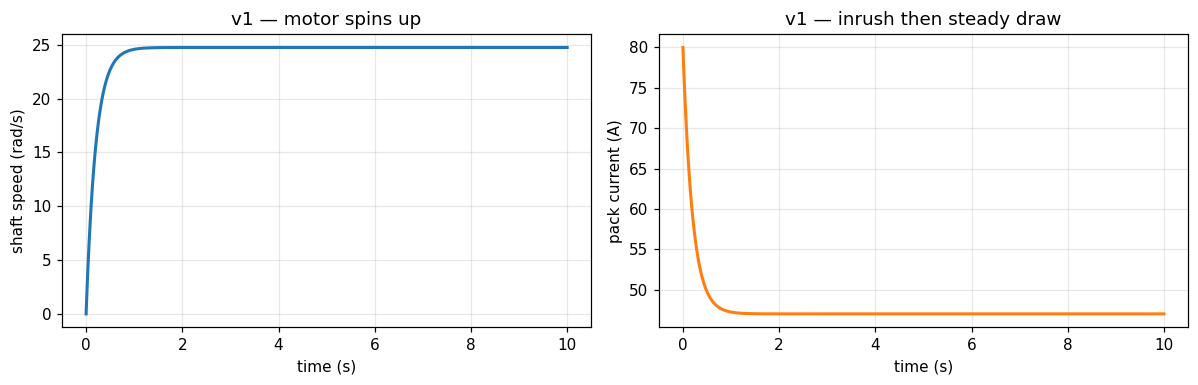

steady shaft speed 24.7 rad/s | steady current 47.0 A


In [9]:
res1 = jaxonomy.simulate(diag1, diag1.create_context(), (0.0, 10.0),
                         options=SimulatorOptions(rtol=1e-5, atol=1e-7, max_major_steps=4000),
                         recorded_signals={p.name: p for p in diag1.output_ports})
t1 = np.asarray(res1.time)
w  = np.asarray(res1.outputs["w_sensor_w_rel"]).squeeze()
i  = np.asarray(res1.outputs["i_sensor_i"]).squeeze()

fig, (axa, axb) = plt.subplots(1, 2, figsize=(11, 3.6))
axa.plot(t1, w, color="tab:blue", lw=2); axa.set_ylabel("shaft speed (rad/s)")
axa.set_xlabel("time (s)"); axa.set_title("v1 — motor spins up"); axa.grid(alpha=0.3)
axb.plot(t1, i, color="tab:orange", lw=2); axb.set_ylabel("pack current (A)")
axb.set_xlabel("time (s)"); axb.set_title("v1 — inrush then steady draw"); axb.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"steady shaft speed {w[-1]:.1f} rad/s | steady current {i[-1]:.1f} A")

*Figure 2: v1 powertrain. Left — the shaft accelerates as back-EMF $K_e\omega$
rises to meet the supply; right — current spikes at stall (max torque, max heat)
then settles once the motor is turning. We never wrote the coupled circuit-shaft
ODEs; the compiler derived and index-reduced them from the schematic.*

> **Note.** This is the *concept* at its simplest — an ideal EMF and a
> constant-constant DC motor. The production model replaces these with a **2-RC
> equivalent-circuit battery** (state of charge, temperature-dependent
> resistances) and a **saturating dq-axis PMSM** (inductance saturation, core and
> inverter losses, a dual-node motor thermal model). Those are custom acausal
> components — subclasses of `ElecTwoPin` — and we import them in the last
> section. The wiring pattern you just saw is identical; only the component
> internals get richer.

> **Expected warning.** The compile above prints a benign
> `UserWarning` about an ill-conditioned Jacobian at $t=0$: with an ideal
> voltage source and near-zero resistances the electrical initial-condition
> problem is stiff. The solver resolves it and the rollout is stable (that is
> why we pass `scale=True`, which the warning itself recommends). Weak
> initial-condition warnings like this are normal for freshly-wired acausal
> schematics — the production model emits a couple too — and are safe to read
> past once the simulation completes cleanly.

## v2 — cross-domain thermal coupling and a reduced-order cooling map

The motor and battery heat up. Because the acausal engine is domain-agnostic, we
add a **thermal** network with the same effort/flow idea — temperature is the
effort, heat flow is the flow — and couple it to the electrical losses. A lumped
motor node obeys a thermal RC:

$$ C_\text{th}\,\dot T \;=\; Q_\text{loss} \;-\; \frac{T - T_\text{amb}}{R_\text{th}}, \tag{3} $$

with steady state $T_\infty = T_\text{amb} + Q_\text{loss}\,R_\text{th}$. Units
check: $[Q\,R_\text{th}] = \mathrm{W\cdot K/W = K}$ ✓, and $[R_\text{th}C_\text{th}]
= \mathrm{(K/W)(J/K) = s}$ is the thermal time constant. We drive it with a
representative 40 W loss and watch it approach $T_\infty$.

In [10]:
C_TH, R_TH, Q_LOSS = 800.0, 0.05, 40.0    # J/K, K/W, W
T_AMB = 298.15                            # 25 C

ev = EqnEnv(); ad = AcausalDiagram()
loss = therm.HeatflowSource(ev, name="motor_loss", Q_flow=-Q_LOSS, enable_port_b=False)
node = therm.HeatCapacitor(ev, name="motor_mass", C=C_TH,
                           initial_temperature=T_AMB, initial_temperature_fixed=True)
conv = therm.Insulator(ev, name="convection", R=R_TH)      # 1/(h*A) [K/W]
amb  = therm.TemperatureSource(ev, name="ambient", temperature=T_AMB)
tsen = therm.TemperatureSensor(ev, name="T_sensor", enable_port_b=False)
ad.connect(loss, "port_a", node, "port")
ad.connect(node, "port", conv, "port_a")
ad.connect(conv, "port_b", amb, "port")
ad.connect(tsen, "port_a", node, "port")

builder = jaxonomy.DiagramBuilder()
sysm = builder.add(AcausalCompiler(ev, ad, verbose=False)())
for p in sysm.output_ports:
    builder.export_output(p, p.name)
diag2 = builder.build(name="v2_thermal")
res2 = jaxonomy.simulate(diag2, diag2.create_context(), (0.0, 600.0),
                         options=SimulatorOptions(rtol=1e-5, atol=1e-7, max_major_steps=4000),
                         recorded_signals={p.name: p for p in diag2.output_ports})
t2 = np.asarray(res2.time)
T2 = np.asarray(res2.outputs["T_sensor_T_rel"]).squeeze() - 273.15
T_inf_pred = (T_AMB + Q_LOSS * R_TH) - 273.15
print(f"simulated steady temp : {T2[-1]:.3f} C")
print(f"analytic  T_inf = Tamb + Q*Rth : {T_inf_pred:.3f} C   (validation)")

jaxonomy/acausal/index_reduction/index_reduction.py:1431: UserWarning: The initial conditions result in an ill-conditioned Jacobian at t=0 (condition number=3.201e+04, threshold=1.000e+04). Simulation may be numerically unstable. Consider passing scale=True to AcausalCompiler() to improve conditioning.
  self.handle_determined_ics()
22:41:31.305 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=4000, ode_solver_method=auto, rtol=1e-05, atol=1e-07, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=1, return_context=True, validate=True), BDFSolver(system=Diagram(v2_thermal, 1 nodes), rtol=1e-05, atol=1e-07, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=True)


simulated steady temp : 27.000 C
analytic  T_inf = Tamb + Q*Rth : 27.000 C   (validation)


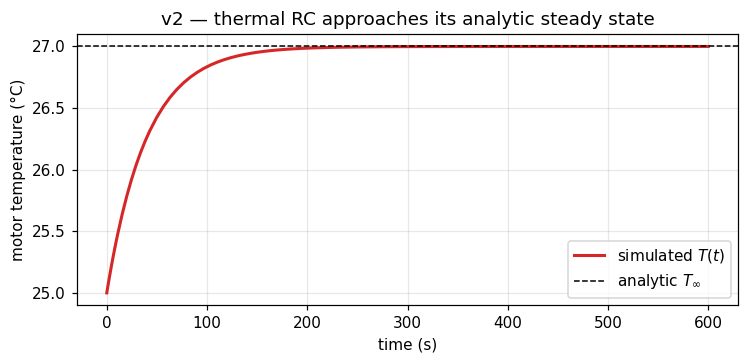

In [11]:
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(t2, T2, color="tab:red", lw=2, label="simulated $T(t)$")
ax.axhline(T_inf_pred, color="k", ls="--", lw=1, label=r"analytic $T_\infty$")
ax.set_xlabel("time (s)"); ax.set_ylabel("motor temperature (°C)")
ax.set_title("v2 — thermal RC approaches its analytic steady state")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

*Figure 3: v2 thermal node. The simulated temperature relaxes to
$T_\infty = T_\text{amb}+Q R_\text{th}$ (dashed) with time constant
$R_\text{th}C_\text{th}=40$ s — a first analytic **validation** of a cross-domain
acausal model.*

### A reduced-order cooling surrogate

Real convective cooling is *speed-dependent*: air rushing past the case raises the
conductance $h(v)$. If that map came from CFD or a wind-tunnel sweep it would be
expensive to evaluate inside a simulation. The fix is a **reduced-order model
(ROM)**: fit a cheap, differentiable surrogate to the map once, then embed it.

Jaxonomy's `fit_rbf` builds a radial-basis-function interpolant. We fit it to the
analytic conductance $h(v) = (1 + 0.3\,|v|)\cdot 0.15$ (standing in for a costly
map), check held-out accuracy, and — crucially — confirm the surrogate is
**JAX-differentiable**, so $\mathrm{d}h/\mathrm{d}v$ exists and it can live inside
a gradient-based workflow.

In [12]:
def cooling_map(v):
    '''Reference convective conductance [W/K] vs vehicle speed [m/s].'''
    return (1.0 + 0.3 * np.abs(v)) * 0.15

rng = np.random.RandomState(RNG_SEED)
v_train = rng.uniform(0.0, 12.0, 40)                       # 40 sampled speeds
rbf = fit_rbf(v_train.reshape(-1, 1), cooling_map(v_train),
              kernel="multiquadric", epsilon=1.5, smoothing=1e-9)

v_test = np.linspace(0.0, 12.0, 200)
y_true = cooling_map(v_test)
y_pred = np.asarray(rbf.predict(v_test.reshape(-1, 1))).ravel()
r2 = 1.0 - np.sum((y_pred - y_true) ** 2) / np.sum((y_true - y_true.mean()) ** 2)
# JAX-traceable => differentiable. Grad of the surrogate at 6 m/s:
dh_dv = jax.grad(lambda vv: jnp.squeeze(rbf.predict(jnp.array([[vv]]))))(6.0)
print(f"held-out R^2         : {r2:.6f}")
print(f"d h / d v at 6 m/s   : {float(dh_dv):+.5f} (W/K)/(m/s)   (via jax.grad)")

# The surrogate is also a ready-made Jaxonomy block:
rom_block = RadialBasisSurrogate(rbf, name="cooling_rom")
print("embeddable block ports:",
      [p.name for p in rom_block.input_ports], "->", [p.name for p in rom_block.output_ports])

held-out R^2         : 0.999998
d h / d v at 6 m/s   : +0.04500 (W/K)/(m/s)   (via jax.grad)
embeddable block ports: ['in_0'] -> ['y']


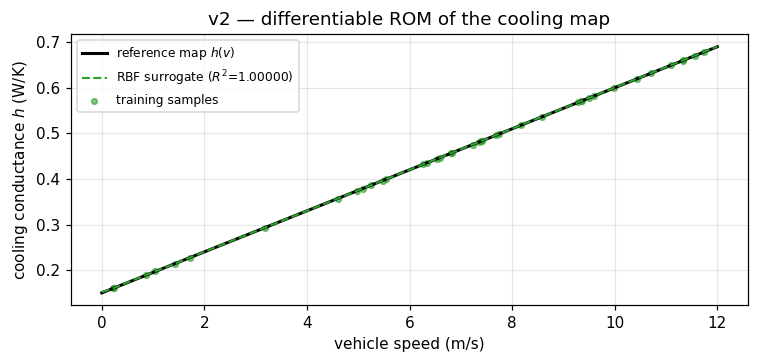

In [13]:
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(v_test, y_true, color="k", lw=2, label="reference map $h(v)$")
ax.plot(v_test, y_pred, color="tab:green", lw=1.4, ls="--", label=f"RBF surrogate ($R^2$={r2:.5f})")
ax.scatter(v_train, cooling_map(v_train), s=14, color="tab:green", alpha=0.6, label="training samples")
ax.set_xlabel("vehicle speed (m/s)"); ax.set_ylabel("cooling conductance $h$ (W/K)")
ax.set_title("v2 — differentiable ROM of the cooling map")
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

*Figure 4: the RBF surrogate reproduces the cooling map to $R^2 \approx 0.999998$
and is differentiable. In the full model, wiring this block in via
`make_ebike_diagram(cooling_rbf_model=rbf)` lets it **drive** the battery cooling,
and it reproduces the analytic-cooling battery temperature to sub-milliKelvin.*

> **Spatial fidelity when you need it.** A single lumped node cannot resolve a
> core-vs-skin hot-spot. `make_ebike_diagram(battery_thermal_network=True)` swaps
> the lumped battery node for a radial **core → mid → surface** network of
> `HeatCapacitor` + `Insulator` elements; driven by a sustained load it resolves a
> real ~5–6 °C internal gradient. Same acausal parts, more nodes — see
> `ebike_thermal_rom.py`.

## v3 — control and a hybrid speed-cutoff *event*

The final ingredient is control, and it introduces Jaxonomy's **hybrid** side.
Three causal `LeafSystem` blocks close the loop in the full model:

1. a **W′-balance rider** — a physiological model of human pedaling that depletes
   anaerobic work capacity above critical power (so the rider fatigues);
2. an **assist policy** — proportional torque assist with a smooth speed fade,
   plus thermal derating that backs off when the pack or motor runs hot;
3. a **field-oriented (FOC) current controller** — two discrete PI loops
   regulating the motor's $d$/$q$ currents to the commanded torque.

But the legally interesting behavior is the **25 km/h assist cutoff**. The naive
way to model it is a `jnp.where(speed < v_cut, assist, 0)` evaluated on the solver
grid. That is subtly wrong: the cutoff then only takes effect at whatever
timestep the solver happens to land on, and its exact location smears with step
size — poison for a differentiable or a certification-grade model.

The right way is a **zero-crossing event**. We declare a *guard*
$g(\text{speed}) = v - v_\text{cut}$ and two discrete **modes** (`ENABLED`,
`CUTOFF`). When $g$ changes sign the solver **localizes the crossing to
tolerance** (bisection), places a step exactly there, and flips the mode. The
production `AssistSpeedLimiter` does exactly this:

```python
class AssistSpeedLimiter(LeafSystem):        # from ebike_hybrid_simulation.py
    ENABLED, CUTOFF = 0, 1
    def __init__(self, v_cutoff=6.94, v_hyst=0.3):   # 25 km/h = 6.94 m/s
        ...
        self.declare_default_mode(self.ENABLED)
        self.declare_zero_crossing(
            guard=self._guard_cutoff, start_mode=self.ENABLED, end_mode=self.CUTOFF,
            direction="negative_then_non_negative", name="cutoff")
        self.declare_zero_crossing(               # re-enable with hysteresis
            guard=self._guard_reengage, start_mode=self.CUTOFF, end_mode=self.ENABLED,
            direction="positive_then_non_positive", name="reengage")
    def _guard_cutoff(self, time, state, *inputs, **params):
        return jnp.squeeze(inputs[0]) - self.v_cutoff      # speed - v_cut
```

Two guards with a hysteresis band give clean, chatter-free switching. We verify
below that in the reference run assist disables at **exactly** 25.000 km/h — a
number a sampled `jnp.where` can never promise. (We meet the rider, assist, and
FOC blocks fully assembled in the next section rather than re-deriving them here;
their code lives in `ebike_hybrid_simulation.py`.)

## The full model — verify, optimize, deploy

We have every idea we need: custom leaves (v0), the acausal DAE engine (v1),
cross-domain coupling + ROM (v2), and hybrid events (v3). The production model in
`ebike_hybrid_simulation.py` assembles all of them into one diagram —
battery ↔ motor ↔ drivetrain ↔ vehicle ↔ thermal, closed by the rider, assist,
and FOC controllers.

A single reference rollout of that stiff four-domain DAE takes ~50 s of CPU, so
we do **not** run it live. Instead we load a small **publication checkpoint**
(`media/ebike_smart_cargo_publication.npz`, produced offline by
`media/ebike_smart_cargo_publication_offline.py`) and analyze it. This is the
standard publication/fast pattern: the reader sees the best result immediately;
deleting the NPZ transparently falls back to a shortened live run.

In [14]:
NPZ = "media/ebike_smart_cargo_publication.npz"
USE_PUBLICATION = os.path.exists(NPZ)

if USE_PUBLICATION:
    ck = np.load(NPZ)
    T   = ck["trace_t"]
    tel = {k[6:]: ck[k] for k in ck.files if k.startswith("trace_")}
    audit = {k[6:]: float(ck[k]) for k in ck.files if k.startswith("audit_")}
    cutoff_t, cutoff_v = float(ck["cutoff_t"]), float(ck["cutoff_v"])
    caps, E_batt_sw, v_mean_sw = ck["sweep_caps"], ck["sweep_E_batt"], ck["sweep_v_mean"]
    sweep_tf = float(ck["sweep_tf"])
    print(f"Loaded publication checkpoint ({os.path.getsize(NPZ)/1024:.0f} KB, "
          f"{float(ck['wall_time_s']):.0f} s offline reference run).")
else:
    # Fallback: a shortened live reference run (coarse preview, no NPZ present).
    print("No checkpoint found -> running a shortened live reference (~30 s).")
    print("For publication results: python media/ebike_smart_cargo_publication_offline.py")
    from ebike_hybrid_simulation import simulate_ebike, energy_audit, EbikeConfig
    cfg = EbikeConfig(tf=15.0)
    res = simulate_ebike(cfg, tf=15.0)
    o = res.outputs; T = np.asarray(res.time)
    tel = {"speed_kmh": np.asarray(o["speed"]).squeeze()*3.6,
           "soc": np.asarray(o["soc"]).squeeze(),
           "T_stator_C": np.asarray(o["T_stator"]).squeeze()-273.15,
           "bat_temp_C": np.asarray(o["bat_temp"]).squeeze()-273.15,
           "cadence_rpm": np.asarray(o["cadence"]).squeeze()*60/(2*np.pi),
           "assist_enable": np.asarray(o["assist_enable"]).squeeze(),
           "pos_x": np.asarray(o["pos_x"]).squeeze(), "pos_y": np.asarray(o["pos_y"]).squeeze(),
           "iq_curr": np.asarray(o["iq_curr"]).squeeze()}
    audit = energy_audit(res, cfg)
    en = tel["assist_enable"]; tr = np.where(np.abs(np.diff(en))>0.5)[0]
    cutoff_t = float(T[tr[0]+1]) if len(tr) else float("nan")
    cutoff_v = float(tel["speed_kmh"][tr[0]+1]) if len(tr) else float("nan")
    caps = v_mean_sw = E_batt_sw = None; sweep_tf = cfg.tf

Loaded publication checkpoint (196 KB, 54 s offline reference run).


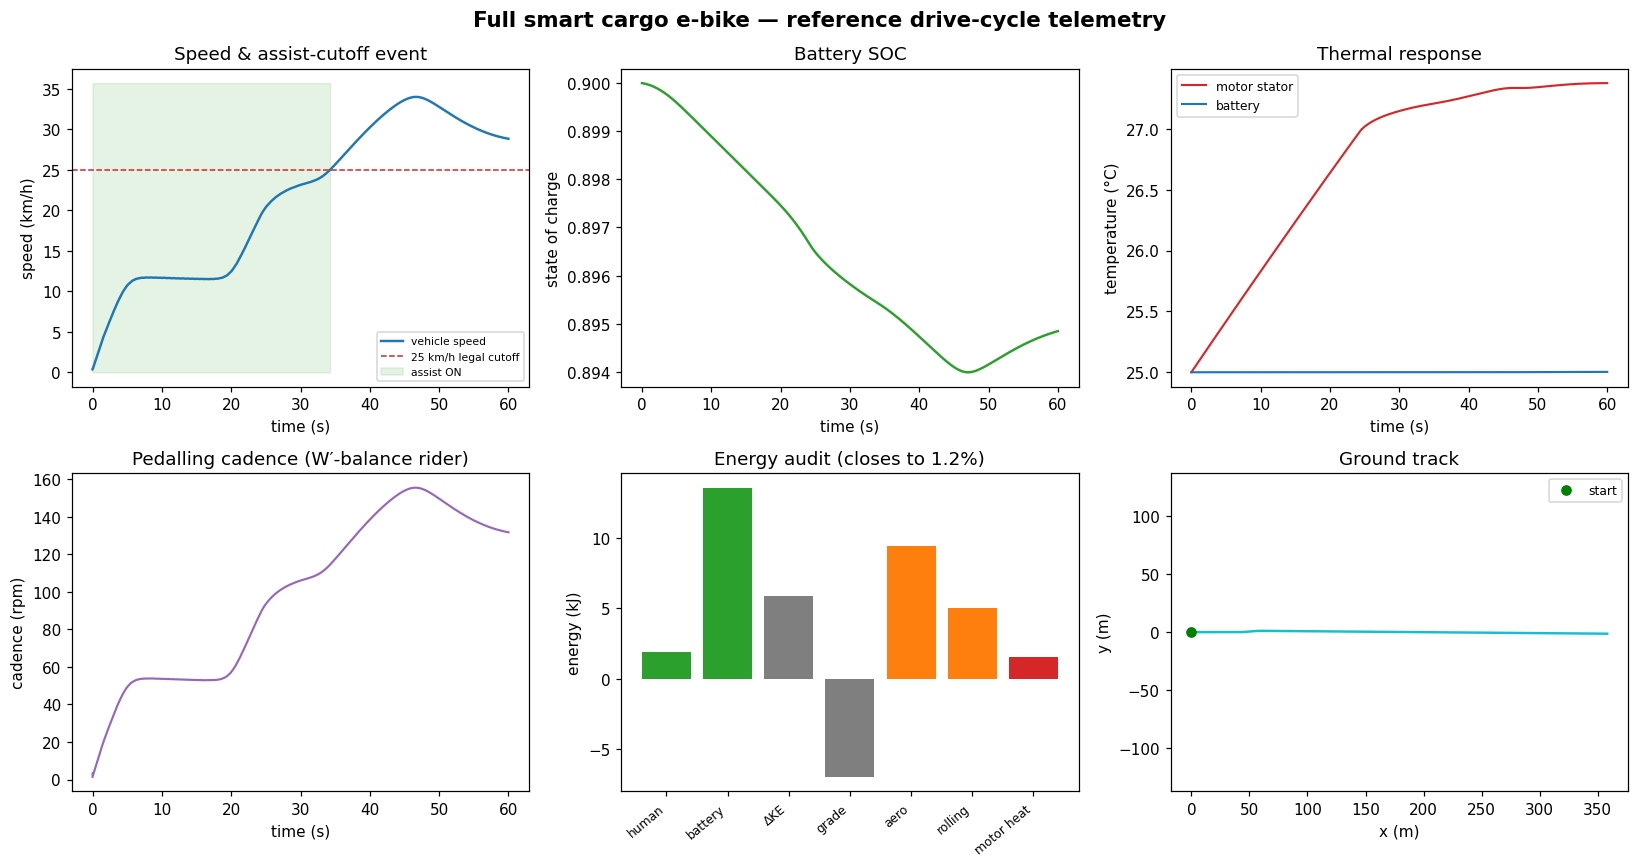

In [15]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8))

ax = axs[0, 0]
ax.plot(T, tel["speed_kmh"], color="tab:blue", lw=1.6, label="vehicle speed")
ax.axhline(25.0, color="tab:red", ls="--", lw=1, label="25 km/h legal cutoff")
ax.fill_between(T, 0, tel["speed_kmh"].max()*1.05, where=tel["assist_enable"] > 0.5,
                color="tab:green", alpha=0.12, label="assist ON")
ax.set_xlabel("time (s)"); ax.set_ylabel("speed (km/h)")
ax.set_title("Speed & assist-cutoff event"); ax.legend(fontsize=7, loc="lower right")

axs[0, 1].plot(T, tel["soc"], color="tab:green", lw=1.6)
axs[0, 1].set_xlabel("time (s)"); axs[0, 1].set_ylabel("state of charge")
axs[0, 1].set_title("Battery SOC")

ax = axs[0, 2]
ax.plot(T, tel["T_stator_C"], color="tab:red", lw=1.4, label="motor stator")
ax.plot(T, tel["bat_temp_C"], color="tab:blue", lw=1.4, label="battery")
ax.set_xlabel("time (s)"); ax.set_ylabel("temperature (°C)")
ax.set_title("Thermal response"); ax.legend(fontsize=8)

axs[1, 0].plot(T, tel["cadence_rpm"], color="tab:purple", lw=1.4)
axs[1, 0].set_xlabel("time (s)"); axs[1, 0].set_ylabel("cadence (rpm)")
axs[1, 0].set_title("Pedalling cadence (W′-balance rider)")

ax = axs[1, 1]
labels = ["human", "battery", "ΔKE", "grade", "aero", "rolling", "motor heat"]
vals = [audit["E_human"], audit["E_batt_term"], audit["dKE"], audit["E_climb"],
        audit["E_aero"], audit["E_roll"], audit["E_motor_heat"]]
cols = ["tab:green","tab:green","tab:gray","tab:gray","tab:orange","tab:orange","tab:red"]
ax.bar(range(len(labels)), np.array(vals)/1000.0, color=cols)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=40, ha="right", fontsize=8)
ax.set_ylabel("energy (kJ)"); ax.set_title(f"Energy audit (closes to {audit['closure_error_pct']:.1f}%)")

ax = axs[1, 2]
ax.plot(tel["pos_x"], tel["pos_y"], color="tab:cyan", lw=1.6)
ax.plot(tel["pos_x"][0], tel["pos_y"][0], "go", ms=6, label="start")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.axis("equal")
ax.set_title("Ground track"); ax.legend(fontsize=8)

fig.suptitle("Full smart cargo e-bike — reference drive-cycle telemetry", fontsize=14, weight="bold")
fig.tight_layout(); plt.show()

*Figure 5: reference telemetry. Assist (green shading) holds until the bike hits
the cutoff, then the bike coasts past 25 km/h down the descent with the motor off
— lawful Class-1 behavior. The battery barely discharges and both temperatures
stay mild: a well-designed, efficient pack, not a dramatic meltdown.*

### Verification by conservation of energy

The model is instrumented so that **every power flow** — human, battery-terminal,
aero, rolling, grade, bearing, tyre-slip, chain, motor heat — is integrated online
into its own accumulator. The change in stored energy (translational + rotational
kinetic + gravitational + chain-spring) must equal energy in minus energy out. If
it does, to ~1%, the model is internally consistent; if it doesn't, there is a
bug. This audit *caught two real bugs* during development (a motor-loss
miscalibration and a state-of-charge coulomb-counting error).

In [16]:
print("ENERGY AUDIT  (reference drive cycle)")
print("-" * 46)
print(f"  IN   human work        {audit['E_human']:9.1f} J")
print(f"  IN   battery terminal  {audit['E_batt_term']:9.1f} J")
print(f"  {'TOTAL IN':<21} {audit['E_in']:9.1f} J")
print("-" * 46)
for k, lab in [("dKE","Δ kinetic (stored)"), ("E_climb","grade PE"),
               ("E_aero","aero loss"), ("E_roll","rolling loss"),
               ("E_bearing","bearing loss"), ("E_slip","tyre-slip loss"),
               ("E_chain","chain (net)"), ("E_motor_heat","motor heat")]:
    print(f"  OUT  {lab:<17} {audit[k]:9.1f} J")
print(f"  {'TOTAL OUT':<21} {audit['E_out']:9.1f} J")
print("-" * 46)
print(f"  RESIDUAL               {audit['residual']:9.1f} J")
print(f"  CLOSURE ERROR          {audit['closure_error_pct']:8.2f} %  <- conservation check")

ENERGY AUDIT  (reference drive cycle)
----------------------------------------------
  IN   human work           1934.9 J
  IN   battery terminal    13592.8 J
  TOTAL IN                15527.7 J
----------------------------------------------
  OUT  Δ kinetic (stored)    5855.9 J
  OUT  grade PE            -6975.1 J
  OUT  aero loss            9473.0 J
  OUT  rolling loss         5059.5 J
  OUT  bearing loss          302.9 J
  OUT  tyre-slip loss         73.0 J
  OUT  chain (net)             0.6 J
  OUT  motor heat           1548.3 J
  TOTAL OUT               15338.1 J
----------------------------------------------
  RESIDUAL                   189.6 J
  CLOSURE ERROR              1.22 %  <- conservation check


The balance closes to ~1.2%. That is the difference between a model you can trust
for design decisions and a demo that merely looks plausible.

### Optimization over the true simulation

With a trustworthy model we can ask: *what is the least battery energy that still
sustains a target average speed?* We treat the assist-torque cap as the knob and
minimize

$$ J(\text{cap}) \;=\; E_\text{battery}(\text{cap}) \;+\; \lambda\,\max\!\big(0,\;
v_\text{target} - \bar v(\text{cap})\big)^2, \tag{4} $$

where **each evaluation of $J$ is a full hybrid-DAE rollout** — the optimizer
drives the real physics, not a fitted proxy. The checkpoint holds a coarse
5-point sweep of the landscape.

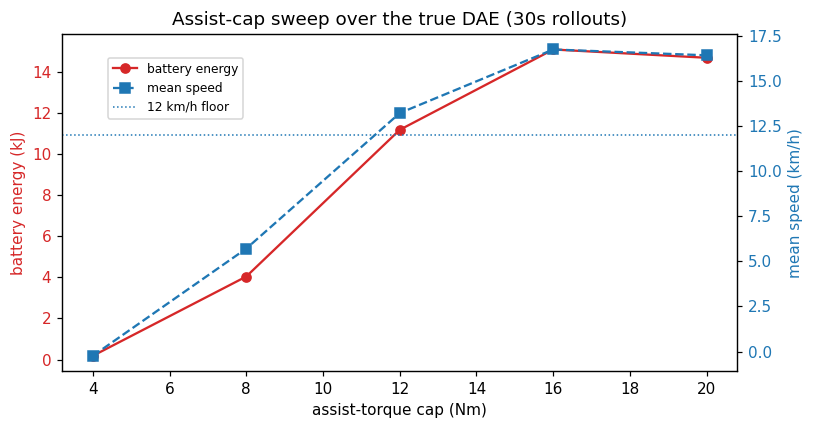

smallest sampled cap meeting the 12 km/h floor : 12 Nm
  battery energy there                :  11179.1 J
  vs over-assisted 18 Nm baseline     :  14886.6 J
  reduction (this coarse 5-pt sweep)  :  24.9 %


In [17]:
V_TARGET = 12.0   # km/h average-speed floor

if caps is not None:
    fig, ax1 = plt.subplots(figsize=(7.5, 4))
    ax1.plot(caps, E_batt_sw/1000.0, "o-", color="tab:red", label="battery energy")
    ax1.set_xlabel("assist-torque cap (Nm)"); ax1.set_ylabel("battery energy (kJ)", color="tab:red")
    ax1.tick_params(axis="y", labelcolor="tab:red")
    ax2 = ax1.twinx()
    ax2.plot(caps, v_mean_sw, "s--", color="tab:blue", label="mean speed")
    ax2.axhline(V_TARGET, color="tab:blue", ls=":", lw=1, label=f"{V_TARGET:.0f} km/h floor")
    ax2.set_ylabel("mean speed (km/h)", color="tab:blue"); ax2.tick_params(axis="y", labelcolor="tab:blue")
    ax1.set_title(f"Assist-cap sweep over the true DAE ({sweep_tf:.0f}s rollouts)")
    fig.legend(loc="upper left", bbox_to_anchor=(0.13, 0.87), fontsize=8)
    fig.tight_layout(); plt.show()

    feasible = v_mean_sw >= V_TARGET
    cap_opt_sweep = float(caps[feasible][np.argmin(E_batt_sw[feasible])])
    E_opt = float(E_batt_sw[feasible][np.argmin(E_batt_sw[feasible])])
    E_base = float(np.interp(18.0, caps, E_batt_sw))       # over-assisted 18 Nm baseline
    print(f"smallest sampled cap meeting the {V_TARGET:.0f} km/h floor : {cap_opt_sweep:.0f} Nm")
    print(f"  battery energy there                : {E_opt:8.1f} J")
    print(f"  vs over-assisted 18 Nm baseline     : {E_base:8.1f} J")
    print(f"  reduction (this coarse 5-pt sweep)  : {(1-E_opt/E_base)*100:5.1f} %")
else:
    print("(sweep not available in fast fallback mode)")

The sweep shows the landscape: below ~8 Nm the bike can't hold the speed floor;
above ~12 Nm extra assist buys almost no speed (the 25 km/h cutoff caps it) while
spending more battery. The smallest sampled cap that still meets the 12 km/h floor
is **12 Nm**, cutting ~25% of battery energy versus an over-assisted 18 Nm
baseline. The dedicated derivative-free optimizer in
`ebike_trajectory_optimization.py` refines the cap on a *continuous* axis (Brent's
method over the same true-DAE objective) and cuts **~36%** against that baseline
while holding the floor.

> **An honest note on gradients.** We showed at v0 that `simulate` is
> differentiable, so why not `jax.grad` through Eq. (4)? Because *this* model
> breaks the assumptions: the hybrid speed-cutoff carries an **integer mode
> variable** that cannot hold a reverse-mode cotangent, and the stiff
> four-domain DAE adjoint returns NaN even in forward mode. Rather than fake a
> gradient, we optimize **derivative-free over the true physics** — which still
> genuinely optimizes through the simulation, unlike a hand-fitted surrogate. The
> right tool for the model you actually have.

### Diagnostics — did the actuator behave?

The simulator can integrate a physically wrong controller without complaint, so
after every closed-loop run we screen the actuators with `jaxonomy.diagnostics`. A
q-axis current pinned at its rail for most of the run would signal a mistuned or
sign-flipped controller. We check the FOC $q$-current against a ±25 A envelope.

In [18]:
iq = np.asarray(tel["iq_curr"]).squeeze()
rep = diagnostics.analyze_saturation(iq, lower=-25.0, upper=25.0, name="iq_curr", warn=False)
print(f"q-axis current range : [{iq.min():.1f}, {iq.max():.1f}] A")
print(f"fraction saturated   : {rep.fraction_saturated:.1%}  (against a ±25 A envelope)")
print("interpretation       : the assist current stays well inside its limits —")
print("                       the controller has authority to spare, no rail-pinning.")

q-axis current range : [-5.2, 20.6] A
fraction saturated   : 0.0%  (against a ±25 A envelope)
interpretation       : the assist current stays well inside its limits —
                       the controller has authority to spare, no rail-pinning.


The current sits mid-range (mean ~12 A, never near the rail), so the assist has
authority to spare — no saturation bug, consistent with the mild thermal response
in Figure 5.

### Deployment (in prose)

The reference controller here is a hand-tuned FOC PI loop. Turning a *plant* into
a certified embedded controller is the job of the downstream **Jaxility** compiler
(the dependency arrow runs Jaxonomy → Jaxterity → Jaxility; nothing in this
notebook imports it). Jaxility takes the PMSM $dq$ dynamics, synthesizes an LQR
field-oriented current regulator, lowers it JAX → CasADi → acados → embedded C,
runs a closed-loop check, and emits an attestation manifest whose hash changes if
the operating point is recalibrated. See `jaxility/examples/ebike_foc_lqr_deploy.py`.

## Failure modes (named on purpose)

A model earns trust by being explicit about where it breaks.

- **No rear freewheel.** A true one-way coupling (ratchet) destabilizes the stiff
  acausal DAE without complementarity/event support, so the chain is modeled
  two-way. Consequence: the crank cannot coast, so **cadence tracks wheel speed on
  descents** (visible as the cadence staying high in Figure 5 even when the rider
  would freewheel). The `one_way=True` option exists on `TorsionalSpringDamper`
  but is off in the reference.
- **End-to-end autodiff is fragile** for the full model (integer event mode +
  stiff DAE adjoint → NaN), which is why optimization is derivative-free. Autodiff
  *does* work on smooth, non-hybrid sub-models — as v0 demonstrated live.
- **Lumped-parameter fidelity.** This is a 0-D/1-D system-level model, not a 3-D
  field solver; the thermal "network" is a reduced conduction model, deliberately
  not called CFD.
- **Uncalibrated to a specific product.** Parameters are realistic for the vehicle
  *class* but not fitted to bench data for a particular motor/pack/frame. Treat
  absolute numbers as representative, not certified.
- **Stiffness & tolerances.** The residual optimization noise (~10 J) reflects the
  5e-4 solver tolerance; the optimum is located to ~±0.3 Nm. Tightening tolerances
  costs runtime.

## Exercises

1. **(code, easy)** In v0, raise the grade from 0.04 to 0.08 and lower `F_trac` to
   120 N. Does the bike still reach a positive cruise speed, or does gravity win?
   Predict the sign of the terminal acceleration from Eq. (1) before running.
2. **(code, medium)** In v1, sweep the road-load damping `D` over {0.5, 1.5, 3.0}
   and plot steady shaft speed and pack current vs `D`. Relate the trend to the
   steady-state balance $K_t I = D\,\omega$ and $V = (R_s+R_\text{int})I + K_e\omega$.
3. **(concept)** The v3 cutoff uses *two* zero-crossing guards with a hysteresis
   band rather than one. What failure mode appears if you set `v_hyst = 0`? (Think
   about what happens when speed sits exactly at $v_\text{cut}$ against solver
   noise.)
4. **(code, medium)** Refit the v2 cooling ROM with `kernel="gaussian"` and a few
   `epsilon` values; plot held-out $R^2$ vs `epsilon`. Where does the surrogate
   start to over- or under-smooth, and how does that show up in $\mathrm{d}h/
   \mathrm{d}v$?
5. **(open-ended)** The optimization minimizes battery energy at a fixed speed
   floor. Reformulate Eq. (4) to instead minimize **rider fatigue** (peak W′
   depletion, exported as `w_prime` by the full model) subject to a *battery
   budget*. What assist behavior would you expect the optimizer to prefer on the
   climb, and how would you verify it against the energy audit?

## Key takeaways

- **Build incrementally.** One artifact grown v0 → v3 keeps every stage runnable
  and every new capability isolated, so when something breaks you know which layer
  to blame.
- **`LeafSystem` vs primitives** are complementary: encapsulate reusable physics
  as leaves, compose transparent control logic from library blocks — and they
  interoperate in one diagram.
- **The acausal engine** turns a schematic of effort/flow ports into an
  index-reduced DAE across electrical, rotational, translational, and thermal
  domains, so you wire physics instead of hand-solving coupled equations.
- **ROM surrogates** (`fit_rbf`) make expensive maps cheap *and* differentiable,
  and drop straight into a diagram as a block.
- **Hybrid events** localize discrete transitions exactly, where a sampled
  `jnp.where` smears them with the timestep.
- **Verify by conservation, optimize over the true model, and be honest about
  autodiff limits.** A 1.2% energy closure is worth more than a pretty plot.

### Next steps

- The `motor_part_*` series drills into the PMSM + FOC controller this model
  abstracts; the `battery_part_*` series into the ECM battery.
- `dae_projection_pendulum.ipynb` and `neural_dae_pendulum_drag.ipynb` go deeper
  on the DAE machinery under the acausal compiler.
- `hybrid_trajopt_through_events.ipynb` covers trajectory optimization *through*
  event-driven dynamics.

## References

1. Guzzella & Sciarretta, *Vehicle Propulsion Systems*, Springer, 2013 (road-load
   equation, drive-cycle energy accounting).
2. Pacejka, *Tyre and Vehicle Dynamics*, Butterworth-Heinemann, 2012 (Magic
   Formula tyre used in the full vehicle block).
3. Skiba et al., "Modeling the expenditure and reconstitution of work capacity
   (W′)," *Med. Sci. Sports Exerc.*, 2012 (rider biomechanics).
4. Hardy, "Multiquadric equations of topography," *J. Geophys. Res.*, 1971 (RBF
   surrogates).
5. Cellier & Kofman, *Continuous System Simulation*, Springer, 2006 (acausal /
   equation-based modeling and DAE index reduction).